# SDOCX Format — Ink Properties

Each stroke's delta data blob contains more than just coordinates. After the coordinate
deltas, there's a **trailing section** with per-point attribute channels (pressure,
timestamp, tilt) and per-stroke properties (color, pen width).

This notebook decodes all of it and produces a full-fidelity rendering.

In [1]:
from pathlib import Path

SAMPLE_HANDWRITTEN = Path("../samples/handwritten.sdocx")
SAMPLE_MEDIA = Path("../samples/quiz.sdocx")
# SAMPLE_HANDWRITTEN = Path("../samples/OnlyPensBlacksize10_260630_120309.sdocx")
SAMPLE_HANDWRITTEN = Path("../samples/OnlyHighlighterBlack_260630_131753.sdocx")
SAMPLE_HANDWRITTEN = Path("../samples/Allsamsungnotes_260630_113259.sdocx")


In [2]:
import sys
sys.path.insert(0, "..")

import io

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from pysdocx import (
    hexdump,
    list_pages,
    load_media_by_index,
    load_note,
    load_page_with_bg,
    parse_page,
    parse_tables,
    parse_typed_text,
    raster_media_indices,
    scan_drawings,
    decode_trailing,
    color_hex,
    GRID_SPACING,
    GRID_ORIGIN,
)

In [3]:
MAX_PRESSURE = 1400.0

In [4]:
page_key, page, bg_color = load_page_with_bg(SAMPLE_HANDWRITTEN)
print(f"Page: {len(page):,} bytes")
print(f"Background: {bg_color}")

Page: 420,041 bytes
Background: #252525


In [5]:
result = parse_page(page)
strokes = result["strokes"]
print(f"Parsed {result['kept']} / {result['stroke_count']} strokes")

Parsed 399 / 399 strokes


---

## Trailing Data Structure

Each stroke's data blob has two regions:

```
+------------------------+----------------------------------------------+
|   Coordinate Deltas    |  Trailing: channels + stroke properties      |
|   (4 bytes per point)  |  [4B gap] [pressure] [time] [tilt] [color+w] |
+------------------------+----------------------------------------------+
```

The trailing section starts **4 bytes** after the coordinate data ends. It contains
**four per-point channels**, each encoded as sign-magnitude byte pairs (same encoding
as coordinates, but 1D — no x/y interleaving), followed by **per-stroke color and pen
width** at the very end.

In [6]:
s = strokes[0]
blob = s["data_blob"]
nc = s["n_coord_bytes"]
n_pts = len(s["points"]) - 1  # delta count (excludes start point)

print(f"Stroke 0: {len(s['points'])} points, {len(blob)} data bytes")
print(f"  Coordinate data:   {nc} bytes")
print(f"  Trailing data:     {len(blob) - nc} bytes")
print(f"  Delta points:      {n_pts}")
print(f"  Per-channel size:  {n_pts * 2} bytes")
print(f"  4 channels + gap:  {n_pts * 2 * 4 + 4} bytes")

Stroke 0: 29 points, 418 data bytes
  Coordinate data:   112 bytes
  Trailing data:     306 bytes
  Delta points:      28
  Per-channel size:  56 bytes
  4 channels + gap:  228 bytes


In [7]:
print("Trailing data (first 64 bytes):")
print(hexdump(blob[nc:], limit=64))

Trailing data (first 64 bytes):
  0000  ba 8c cb 3d 01 01 bd 00 8c 00 81 00 7f 00 7f 00  ···=············
  0010  74 00 5c 00 45 00 32 00 1e 00 14 00 04 00 08 00  t·\·E·2·········
  0020  06 00 06 00 0d 00 04 00 02 80 08 80 1b 80 2e 80  ··············.·
  0030  4e 80 7a 80 b6 80 20 81 7c 81 0c 82 00 00 00 00  N·z··· ·|·······
  ... (242 more bytes)


---

## Per-Stroke Color, Width, Tool, and Intensity

Color, pen tool, and pen width are stored at the **end** of the data blob (within the last
~100 bytes — search only the tail, not the whole blob, or you'll occasionally match this same
6-byte shape by coincidence inside the per-point channel data on long, low-variance strokes),
preceded by a 6-byte marker:

```
02 00 TT 00 00 00
```

`TT` encodes **which pen tool** drew the stroke: `tool_id = (TT - 1) / 2`. This is **not a
single global registry** — confirmed on two ground-truth files (one stroke/size per tool,
left to right):

- `samples/OnlyPensBlacksize10_*.sdocx`: `0`=pen, `1`=fountain pen, `2`=calligraphy pen,
  `3`=pencil, `4`=calligraphy brush (all odd `TT`).
- `samples/OnlyHighlighterBlack_*.sdocx`: "highlighter" reuses `TT=1` (same as "pen"!),
  "marker pen" uses `TT=4` (even). The two "straight-line" (ruler-mode) variants use a
  **short-form marker** without the leading `02 00`: `[TT 00 00 00] [BGRA] [f32 width]`.

After the marker, the layout is either `[BGRA][f32 width]` (explicit color) or `[f32 width]`
directly (default ink, no color):

- **alpha (4th color byte) `= 0xFF`** → full-opacity color, then width.
- **leading 4 bytes are a sane width float** → no color, width stored directly (default ink).
- **otherwise** → reduced-opacity color, where the **alpha byte is the pen's "intensità"
  (opacity) slider**: e.g. pencil at intensity 100 = alpha `0xFF`, intensity 50 = `0x80`,
  intensity 0 = `0x03` (low but non-zero — still faintly visible, as in the app). Decoded into
  the per-stroke `intensity` field (0-255).

Ink-pen-category tools also carry a 12-byte block after the width (`[u32 = 2·tool_id][width
repeated]`) that highlighter/marker tools lack — this is the `tapered` flag (pressure-sensitive
nib vs. flat felt tip).

In [8]:
colors = {}
widths = []

for s in strokes:
    key = color_hex(s["color"]) or "(default)"
    colors[key] = colors.get(key, 0) + 1
    widths.append(s["pen_width"])

print("Color distribution:\n")
for color, count in sorted(colors.items(), key=lambda x: -x[1]):
    print(f"  {color:<12} {count:>5} strokes")

# tool_id is a per-category slot index, not a global tool registry (see the
# markdown above) — only label it by name if you know which ground-truth
# file is loaded; otherwise just look at the raw id.
print("\nPer-stroke tool_id/width (sorted left-to-right by bbox.x_min — compare")
print("against the order you actually drew the strokes in, if this is a ground-truth file):\n")
print(f"  {'idx':>4} {'tool_id':>7} {'width':>7} {'x_min':>8}")
for idx, s in sorted(enumerate(strokes), key=lambda pair: pair[1]["bbox"][0]):
    print(f"  {idx:>4} {str(s['tool_id']):>7} {s['pen_width']:>7.2f} {s['bbox'][0]:>8.1f}")

Color distribution:

  #252525        187 strokes
  #ffcb30         65 strokes
  (default)       35 strokes
  #ff3636         32 strokes
  #1447ff         32 strokes
  #2febd2         31 strokes
  #9933ff         17 strokes

Per-stroke tool_id/width (sorted left-to-right by bbox.x_min — compare
against the order you actually drew the strokes in, if this is a ground-truth file):

   idx tool_id   width    x_min
     1       0    1.97    133.2
    41       0    6.35    135.3
    40       0    6.35    135.9
     0       0    1.97    138.9
    77       1    7.89    151.1
   112       1    7.89    151.2
   144       1    4.45    151.2
   111       1    7.89    152.2
   267       3    2.31    152.5
   369       4   15.61    153.4
   301       3    2.31    156.1
    76       1    7.89    156.2
   143       1    4.45    156.7
   268       3    2.31    157.3
   368       4   15.61    158.3
    42       0    6.35    159.0
   338       4   13.97    159.3
   195       2    9.34    160.4
     3    

In [9]:
print(f"Pen width range: {min(widths):.2f} \u2013 {max(widths):.2f}")
print(f"Unique widths:   {sorted(set(f'{w:.2f}' for w in widths))}")

Pen width range: 1.97 – 15.61
Unique widths:   ['1.97', '13.97', '15.61', '2.31', '4.45', '6.35', '7.71', '7.89', '9.34']


---

## Per-Point Pressure

The first per-point channel encodes **pen pressure**. Like coordinates, it uses
sign-magnitude byte pairs — but these are **1D deltas** (not x/y pairs).

Each pair: `(magnitude, sign_flag)` where `0x00` = positive, `0x80` = negative.

The cumulative sum of pressure deltas gives the actual raw pressure at each point,
ranging **0–~1400**, with a characteristic ramp-up at pen-down and sharp drop at
pen-lift. `pysdocx.decode_trailing` (already run for us inside `parse_page`)
normalizes this to **0.0–1.0** and stores it on each stroke as `pressures`.

In [10]:
has_pressure = sum(1 for s in strokes if s["pressures"])
print(f"Strokes with pressure data: {has_pressure} / {len(strokes)}")

Strokes with pressure data: 399 / 399


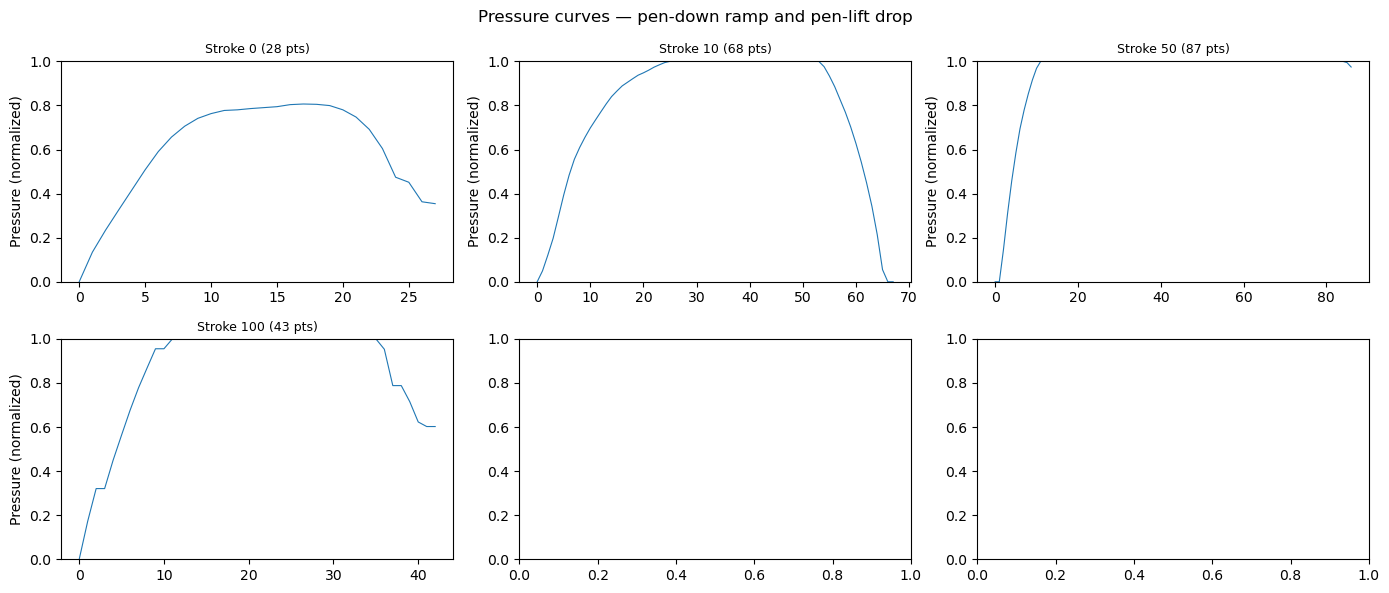

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))

for ax, idx in zip(axes.flat, [0, 10, 50, 100, 500, 1000]):
    if idx < len(strokes) and strokes[idx]["pressures"]:
        p = strokes[idx]["pressures"]
        ax.plot(p, linewidth=0.8)
        ax.set_title(f"Stroke {idx} ({len(p)} pts)", fontsize=9)
        ax.set_ylabel("Pressure (normalized)")
        ax.set_ylim(0, 1)

fig.suptitle(
    "Pressure curves — pen-down ramp and pen-lift drop",
    fontsize=12,
)
plt.tight_layout()
plt.show()

---

## All Per-Point Channels

After the 4-byte gap, there are **four consecutive channels**, each with `n_points`
sign-magnitude delta pairs:

| Channel | Offset from trail start | Content |
|---------|------------------------|---------|
| 0 | `0` | Pressure (0–1400) |
| 1 | `n_points x 2` | Timestamp (monotonic) |
| 2 | `n_points x 4` | Tilt X |
| 3 | `n_points x 6` | Tilt Y |

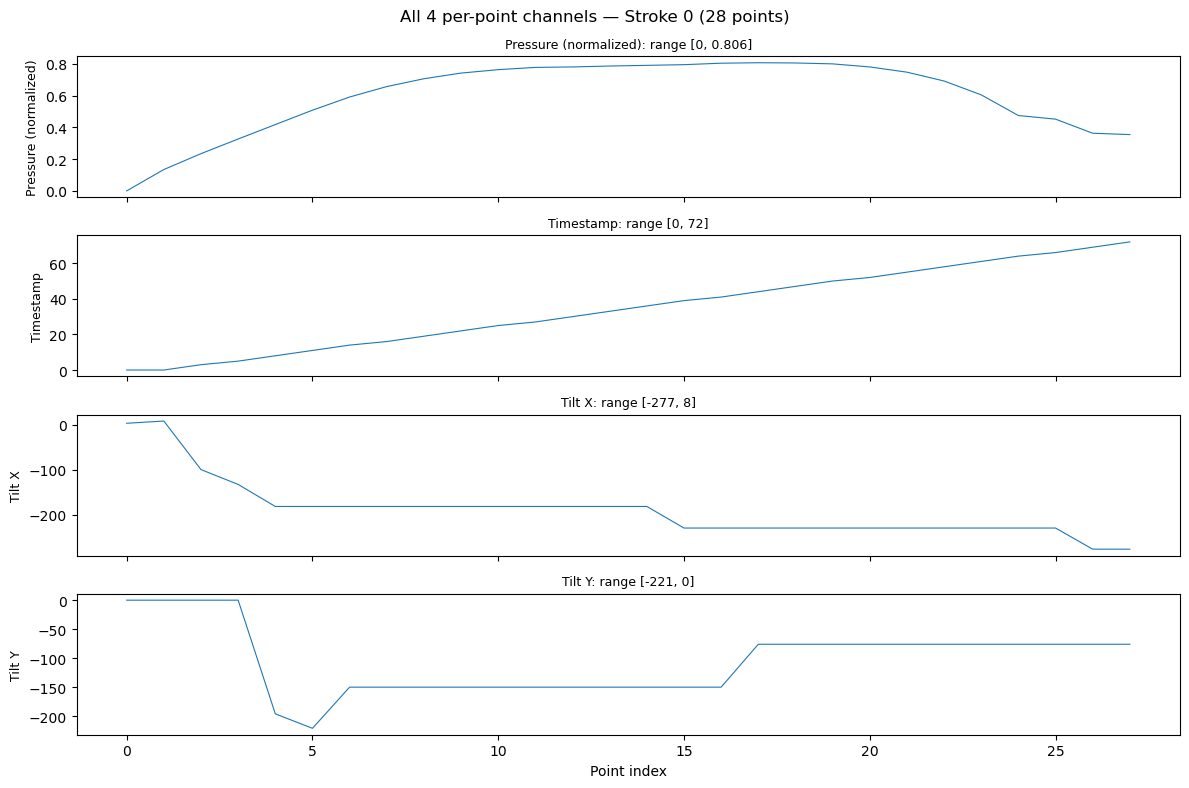

In [12]:
s = strokes[0]
n_pts = len(s["points"]) - 1
trailing = decode_trailing(s["data_blob"], s["n_coord_bytes"], n_pts)
channels = [trailing["pressures"], trailing["timestamps"], trailing["tilt_x"], trailing["tilt_y"]]
ch_names = ["Pressure (normalized)", "Timestamp", "Tilt X", "Tilt Y"]

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
for ax, ch, name in zip(axes, channels, ch_names):
    if ch:
        ax.plot(ch, linewidth=0.8)
        ax.set_ylabel(name, fontsize=9)
        ax.set_title(f"{name}: range [{min(ch):.3g}, {max(ch):.3g}]", fontsize=9)
axes[-1].set_xlabel("Point index")
fig.suptitle(
    f"All 4 per-point channels — Stroke 0 ({n_pts} points)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

---

## Full Rendering

Combining everything: coordinates from delta decoding, per-stroke color from the
color marker, and per-point pressure for variable stroke width.

Width formula:
```
base_width  = pen_width / 2.5
segment_width = base_width x (0.3 + 0.7 x normalized_pressure)
```

Where `normalized_pressure = clamp(cumulative_pressure / 1400, 0, 1)`.

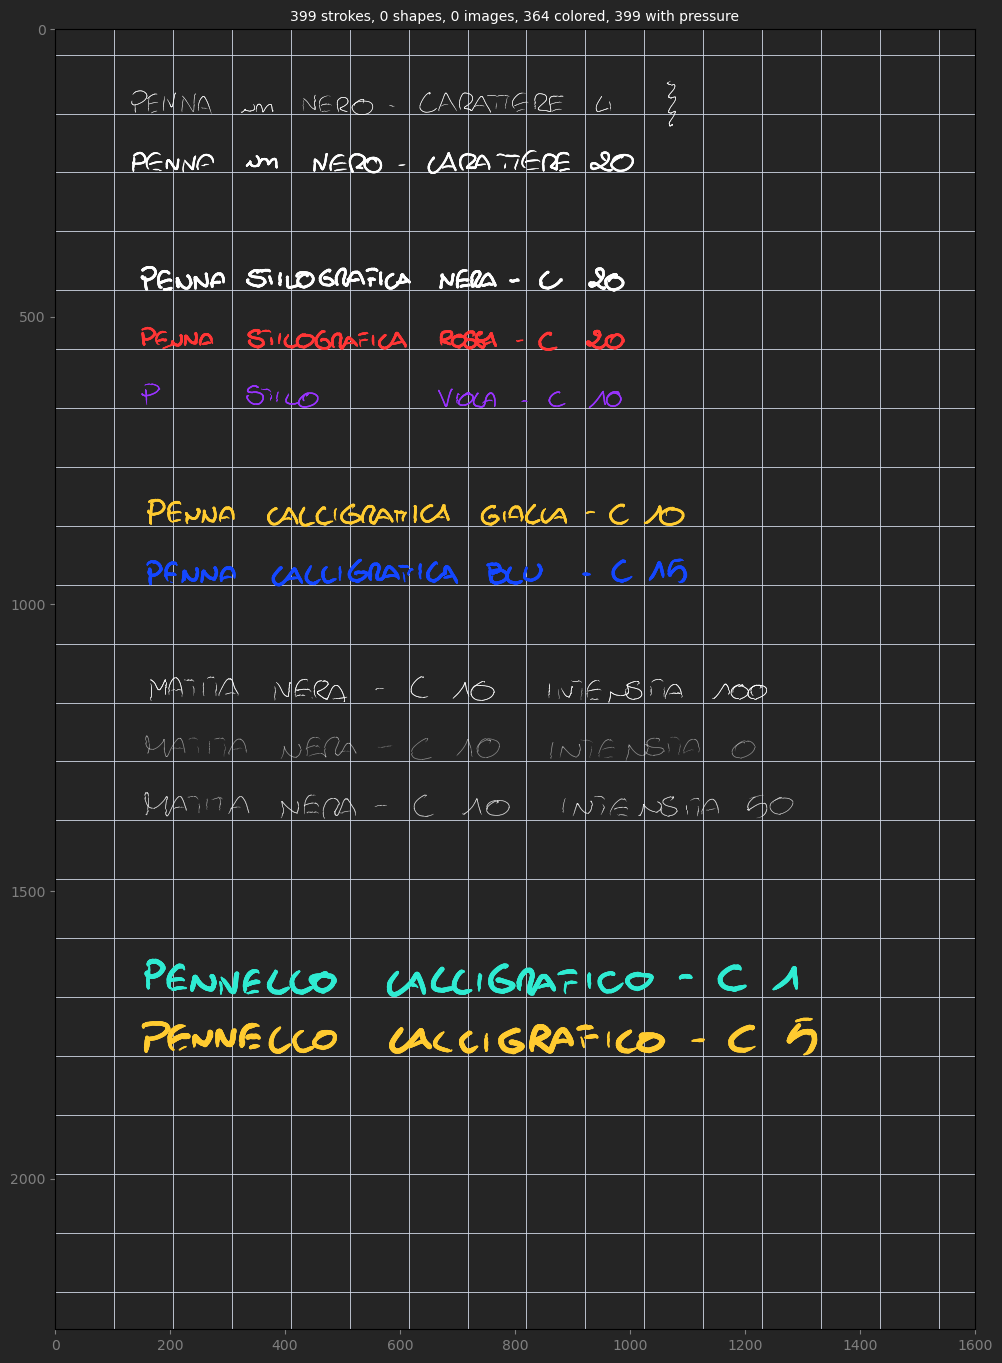

In [13]:
import math

from matplotlib.collections import LineCollection

DEFAULT_INK = "#ffffff"
GRID_COLOR = "#d3dae8"  # faint blue-gray, as in the Samsung Notes squared template


def draw_grid(ax, width, height, spacing=GRID_SPACING, origin=GRID_ORIGIN, color=GRID_COLOR, lw=0.6):
    """Draw the squared-paper template: light vertical + horizontal lines every `spacing`
    page units, spanning the whole page (0..width, 0..height). `origin` is the page-coord
    position of a grid line on each axis (the template has a ~44px top margin, so vertical
    lines start at x=0 but horizontal ones start ~44px down) — measured from the GT photos."""
    xs = np.arange(origin[0] % spacing, width + 0.5, spacing)
    ys = np.arange(origin[1] % spacing, height + 0.5, spacing)
    segments = [((x, 0.0), (x, height)) for x in xs] + [((0.0, y), (width, y)) for y in ys]
    ax.add_collection(LineCollection(segments, colors=color, linewidths=lw, zorder=0.5))


def catmull_rom_closed(points, per_seg=20):
    """Closed uniform Catmull-Rom spline through the control points, for smooth shapes."""
    p = np.asarray(points, dtype=float)
    n = len(p)
    out = []
    for i in range(n):
        p0, p1, p2, p3 = p[(i - 1) % n], p[i], p[(i + 1) % n], p[(i + 2) % n]
        for t in np.linspace(0, 1, per_seg, endpoint=False):
            out.append(
                0.5
                * (
                    (2 * p1)
                    + (-p0 + p2) * t
                    + (2 * p0 - 5 * p1 + 4 * p2 - p3) * t**2
                    + (-p0 + 3 * p1 - 3 * p2 + p3) * t**3
                )
            )
    out.append(out[0])
    return np.asarray(out)


def shape_is_angular(points, sharp_deg=110, min_sharp=2):
    """Classify a shape's control points as a straight-edged polygon vs a smooth curve.

    Inserted shapes carry no decodable "type" flag next to their vertices, so we split
    them geometrically: a shape with >= `min_sharp` corners whose interior turn exceeds
    `sharp_deg` is angular (triangle / trapezoid / zigzag); otherwise it's smooth (circle,
    rounded blob, S-curve). Heuristic tuned on benchmark page f5b90a84 — it cleanly
    separates the 6 shapes there (angular ones have >=2 corners > 110 deg, smooth ones <=1).
    """
    p = points
    n = len(p)
    sharp = 0
    for i in range(n):
        a, b, c = p[(i - 1) % n], p[i], p[(i + 1) % n]
        v1 = (b[0] - a[0], b[1] - a[1])
        v2 = (c[0] - b[0], c[1] - b[1])
        m1 = math.hypot(*v1)
        m2 = math.hypot(*v2)
        if m1 < 1e-6 or m2 < 1e-6:
            continue
        cos = max(-1.0, min(1.0, (v1[0] * v2[0] + v1[1] * v2[1]) / (m1 * m2)))
        if math.degrees(math.acos(cos)) > sharp_deg:
            sharp += 1
    return sharp >= min_sharp


def render_page(ax, strokes, bg_color, title=None, shapes=(), images=(), page_size=None, template=None):
    """Draw a parsed page (strokes, inserted shapes, imported images) onto a matplotlib Axes.

    `images` is a list of {"bbox": (x0, y0, x1, y1), "data": <image bytes>}. When `page_size`
    (width, height) is given, the axes are fixed to the whole page (not autoscaled to content)
    and, if `template` is a grid template, the squared background is drawn under everything.
    """
    ax.set_facecolor(bg_color)

    # Squared-paper background goes above the flat fill but below images/strokes.
    if page_size is not None and template is not None and template["kind"] == "grid":
        draw_grid(ax, page_size[0], page_size[1])

    # Imported images go underneath everything else. The axis is y-inverted at
    # the end (page coords have y increasing downward), so use origin="lower"
    # with the natural extent to keep the picture itself upright.
    for im in images:
        x0, y0, x1, y1 = im["bbox"]
        pic = np.asarray(Image.open(io.BytesIO(im["data"])).convert("RGB"))
        ax.imshow(pic, extent=(x0, x1, y0, y1), origin="lower", aspect="auto", zorder=1)

    for s in strokes:
        pts = s["points"]
        if len(pts) < 2:
            continue

        color = color_hex(s["color"])
        # A stroke whose decoded color matches the canvas exactly is using the
        # "default ink" indicator, not a deliberate same-as-background color —
        # fall back to a contrasting ink so it's actually visible.
        if color is None or color == bg_color:
            color = DEFAULT_INK
        base_w = s["pen_width"] / 4
        pressures = s["pressures"]  # already normalized 0..1

        # The BGRA alpha byte is the pen's "intensità" (opacity) slider, 0-255.
        # Map it to a render opacity floored at 0.3 so even intensity 0 (alpha
        # ~3) stays visible, as it does in Samsung Notes, while 50/100 differ.
        opacity = 0.3 + 0.7 * (s["intensity"] / 255)

        pts_arr = np.array(pts)
        segments = np.stack([pts_arr[:-1], pts_arr[1:]], axis=1)

        # Only ink-pen-category tools (s["tapered"]) have pressure-sensitive
        # width (fountain/calligraphy-nib effect) — highlighters/markers are
        # flat felt tips and render at a constant width regardless of
        # per-point pressure.
        if s["tapered"] and len(pressures) >= len(pts) - 1:
            p_norm = np.clip(np.array(pressures[: len(pts) - 1]), 0, 1)
            widths = base_w * (0.3 + 0.7 * p_norm)
        else:
            widths = np.full(len(segments), base_w)

        lc = LineCollection(
            segments, linewidths=widths, colors=color, capstyle="round", alpha=opacity, zorder=2
        )
        ax.add_collection(lc)

    # Inserted shapes (rect/ellipse/line/regular polygon) are absolute-coord control
    # points with their own BGRA color. There's no decodable shape-type flag next to
    # them, so we classify angular vs smooth geometrically (shape_is_angular): straight
    # polygons (triangle/trapezoid/zigzag) are drawn as closed outlines, smooth ones
    # (circle/rounded blob/S) through a closed Catmull-Rom spline. Same color==background
    # fallback as strokes so dark shapes stay visible. Known limitation: the trapezoid's
    # 4 control points are its edge midpoints, so it reconstructs as a diamond.
    for sh in shapes:
        r, g, b = sh["color"]
        color = f"#{r:02x}{g:02x}{b:02x}"
        if color == bg_color:
            color = DEFAULT_INK
        if shape_is_angular(sh["points"]):
            poly = sh["points"] + [sh["points"][0]]  # close the polygon
            xs = [p[0] for p in poly]
            ys = [p[1] for p in poly]
        else:
            curve = catmull_rom_closed(sh["points"])
            xs, ys = curve[:, 0], curve[:, 1]
        ax.plot(xs, ys, "-", color=color, linewidth=2.5, zorder=2)

    if page_size is not None:
        # Fix the view to the whole page so the grid fills it and content sits in place.
        ax.set_xlim(0, page_size[0])
        ax.set_ylim(page_size[1], 0)  # y increases downward in page coords
    else:
        ax.autoscale()
        ax.invert_yaxis()
    ax.set_aspect("equal")
    if title is None:
        title = (
            f"{len(strokes)} strokes, {len(shapes)} shapes, {len(images)} images, "
            f"{sum(1 for s in strokes if s['color'])} colored, "
            f"{sum(1 for s in strokes if s['pressures'])} with pressure"
        )
    ax.set_title(title, color="white", fontsize=10)
    ax.tick_params(colors="gray")


fig, ax = plt.subplots(figsize=(10, 14))
fig.patch.set_facecolor(bg_color)
render_page(
    ax, strokes, bg_color, shapes=result["shapes"],
    page_size=(result["width"], result["height"]), template=result["template"],
)
plt.tight_layout()
plt.show()

In [14]:
# Typed ("keyboard") rich text lives in the container's note.note, not in a .page file — see
# pysdocx.parse_typed_text. Samsung Notes stores the whole document's typed text there with
# per-run bold/italic/underline and per-run color. We render it as styled segments laid out
# left-to-right, measuring each segment's real width with the renderer so proportional-font
# spacing stays correct. Known gaps (not present as run markers, so not rendered): the numbered/
# bullet/todolist prefixes and the "cancellato" strikethrough.
TEXT_DEFAULT_COLOR = (37, 37, 37)  # body default; ≈ the dark page bg, so we contrast it below
TABLE_LINE_COLOR = "#8a8f9a"


def _char_styles(parsed):
    """Expand per-run styles into per-character (bold, italic, underline, color) arrays."""
    n = len(parsed["text"])
    bold = [False] * n
    italic = [False] * n
    underline = [False] * n
    color = [None] * n
    for r in parsed["runs"]:
        for i in range(r["start"], min(r["end"], n)):
            if r["style"] == "bold":
                bold[i] = True
            elif r["style"] == "italic":
                italic[i] = True
            elif r["style"] == "underline":
                underline[i] = True
    for c in parsed["colors"]:
        if c["color"] != TEXT_DEFAULT_COLOR:  # default color is handled by the contrast fallback
            for i in range(c["start"], min(c["end"], n)):
                color[i] = c["color"]
    return bold, italic, underline, color


def render_typed_text(ax, parsed, bg_color, x0=64, y0=80, line_h=60, blank_h=34, fontpt=17):
    """Draw parsed typed text onto the axes with inline bold/italic/underline/color.

    The default text color equals the dark page background, so it falls back to white (same idea
    as the stroke renderer); explicit colors (e.g. red "testorosso") are kept.
    """
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    inv = ax.transData.inverted()
    bold, italic, underline, color = _char_styles(parsed)

    gi = 0
    y = y0
    for line in parsed["text"].split("\n"):
        if not line:
            gi += 1
            y += blank_h
            continue
        x = x0
        i = 0
        while i < len(line):
            style = (bold[gi + i], italic[gi + i], underline[gi + i], color[gi + i])
            j = i
            while j < len(line) and (bold[gi + j], italic[gi + j], underline[gi + j], color[gi + j]) == style:
                j += 1
            seg = line[i:j]
            b, it, u, c = style
            hexc = f"#{c[0]:02x}{c[1]:02x}{c[2]:02x}" if c else DEFAULT_INK
            t = ax.text(
                x, y, seg, color=hexc, fontsize=fontpt, va="top", ha="left", zorder=3,
                fontweight="bold" if b else "normal", fontstyle="italic" if it else "normal",
            )
            corners = inv.transform(t.get_window_extent(renderer).corners())
            w = corners[:, 0].max() - corners[:, 0].min()
            if u:
                y_bottom = corners[:, 1].max()
                ax.plot([x, x + w], [y_bottom, y_bottom], "-", color=hexc, lw=1.3, zorder=3)
            x += w
            i = j
        gi += len(line) + 1
        y += line_h


def render_table(ax, table, line_color=TABLE_LINE_COLOR, text_color=DEFAULT_INK, fontpt=15, pad=18):
    """Draw a table (from pysdocx.parse_tables) as a grid of cells with their text.

    The table's cell texts + geometry live in note.note (like the typed text); parse_tables
    reconstructs the row/column grid from the cell anchor points. Text is drawn light for
    contrast on the dark page background.
    """
    x_edges, y_edges = table["x_edges"], table["y_edges"]
    for x in x_edges:
        ax.plot([x, x], [y_edges[0], y_edges[-1]], "-", color=line_color, lw=1.2, zorder=2)
    for y in y_edges:
        ax.plot([x_edges[0], x_edges[-1]], [y, y], "-", color=line_color, lw=1.2, zorder=2)
    for cell in table["cells"]:
        cx = x_edges[cell["col"]] + pad
        cy = (y_edges[cell["row"]] + y_edges[cell["row"] + 1]) / 2
        ax.text(cx, cy, cell["text"], color=text_color, fontsize=fontpt, va="center", ha="left", zorder=3)

---

## Multi-Page Rendering

Multi-page files (e.g. the benchmark `Allsamsungnotes_*.sdocx`) have several `.page` entries.
`list_pages` returns them in **true document order** (from `pageIdInfo.dat`, not sorted by UUID —
sorting scrambles the order). Each page is rendered full size, one below the other, with its
page index, UUID, parsed/total stroke counts (flagging any mismatch), and background color.

In [15]:
all_pages = list_pages(SAMPLE_HANDWRITTEN)
print(f"{len(all_pages)} page(s) in {SAMPLE_HANDWRITTEN.name} (document order):")
for i, page_name in enumerate(all_pages, start=1):
    _, page_bytes, _ = load_page_with_bg(SAMPLE_HANDWRITTEN, page_name)
    r = parse_page(page_bytes)
    flag = "  MISMATCH" if r["kept"] != r["stroke_count"] else ""
    shp = f"  +{len(r['shapes'])} shapes" if r["shapes"] else ""
    print(f"  page {i}: {page_name[:8]}  {r['kept']:>4}/{r['stroke_count']:<4} strokes{shp}{flag}")

6 page(s) in Allsamsungnotes_260630_113259.sdocx (document order):
  page 1: e955e72c   399/399  strokes
  page 2: e9561382   207/207  strokes
  page 3: f5b90a84    34/52   strokes  +6 shapes  MISMATCH
  page 4: 73920cee    53/81   strokes  MISMATCH
  page 5: a477774a     0/0    strokes
  page 6: 60141c92     0/0    strokes


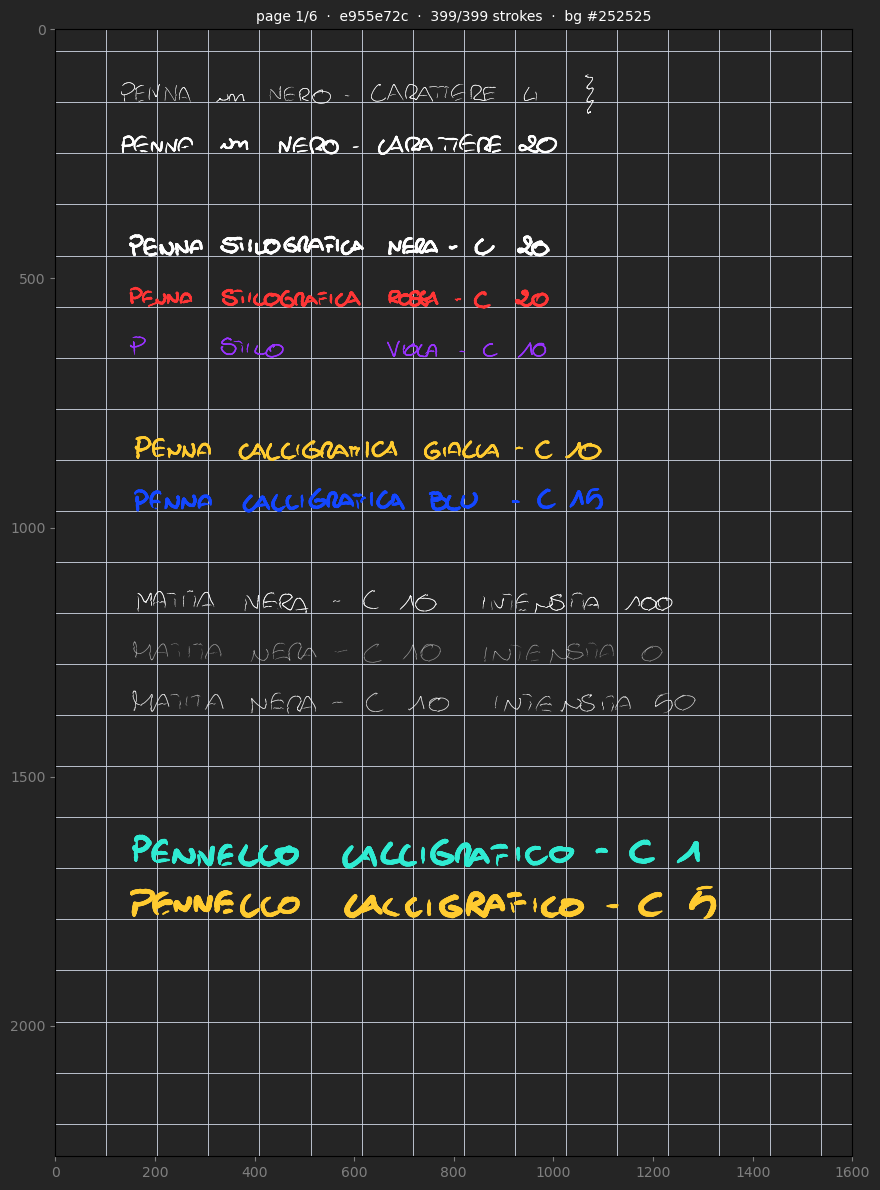

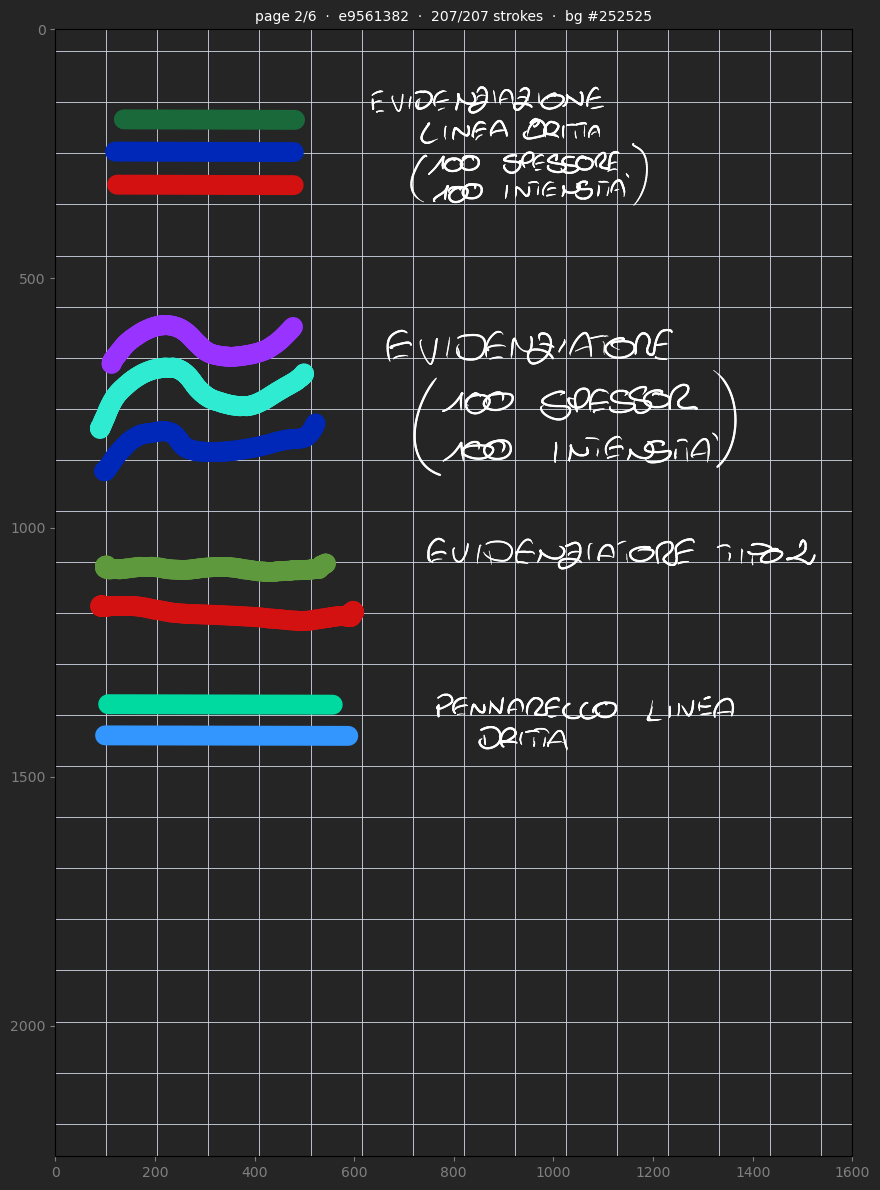

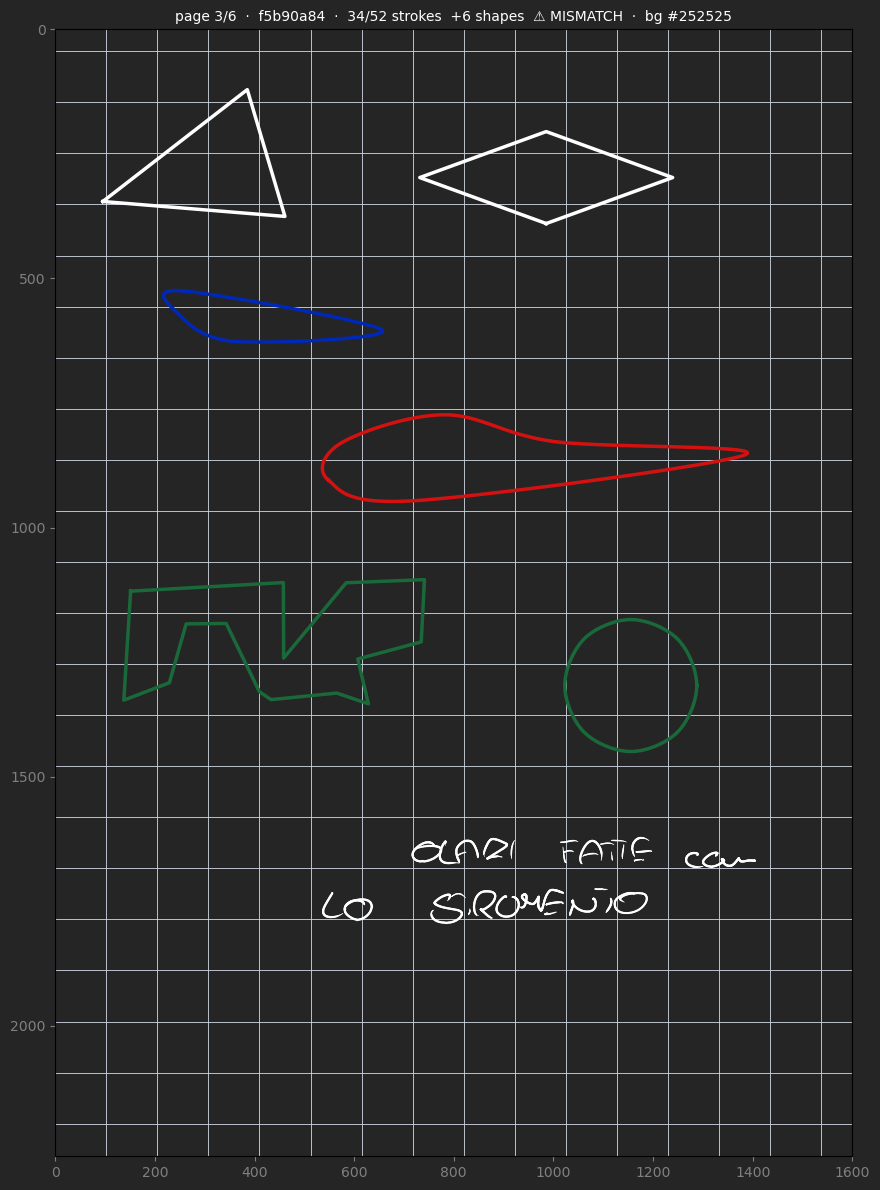

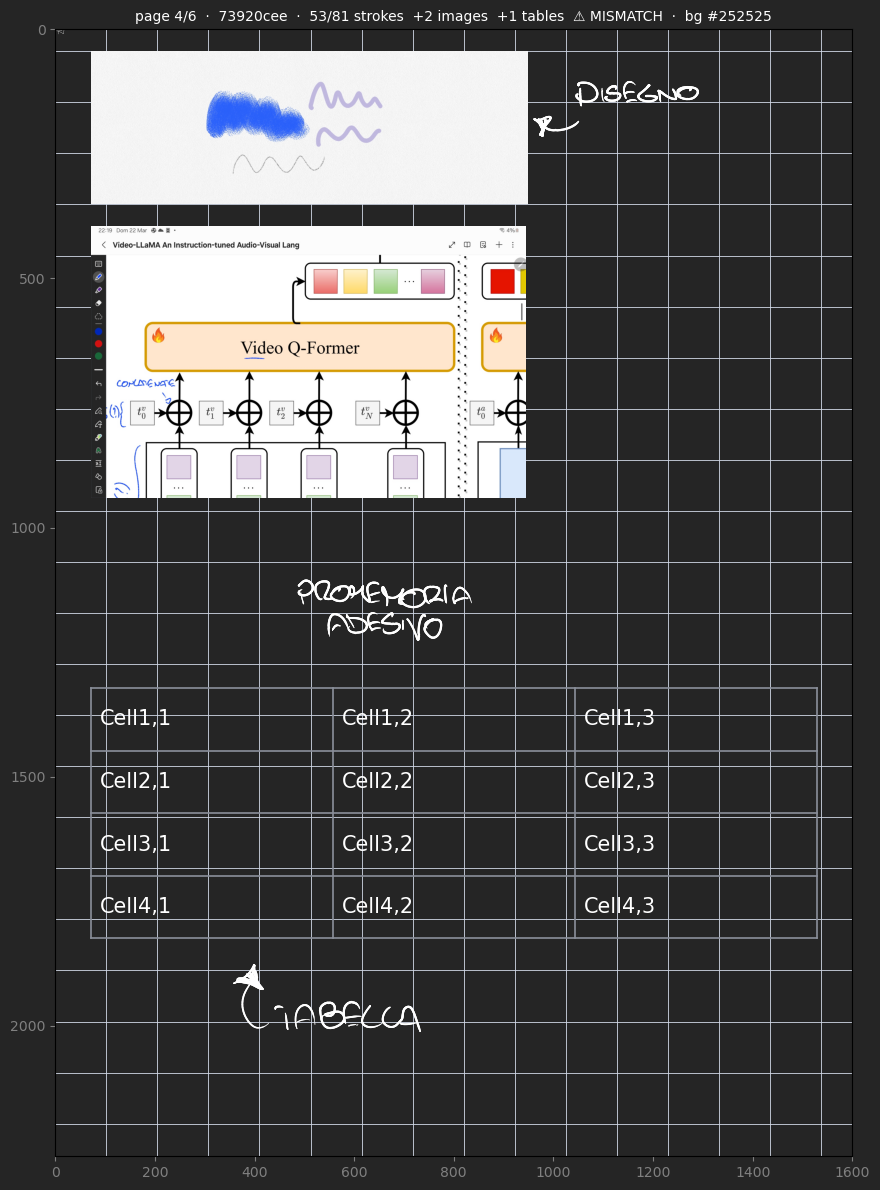

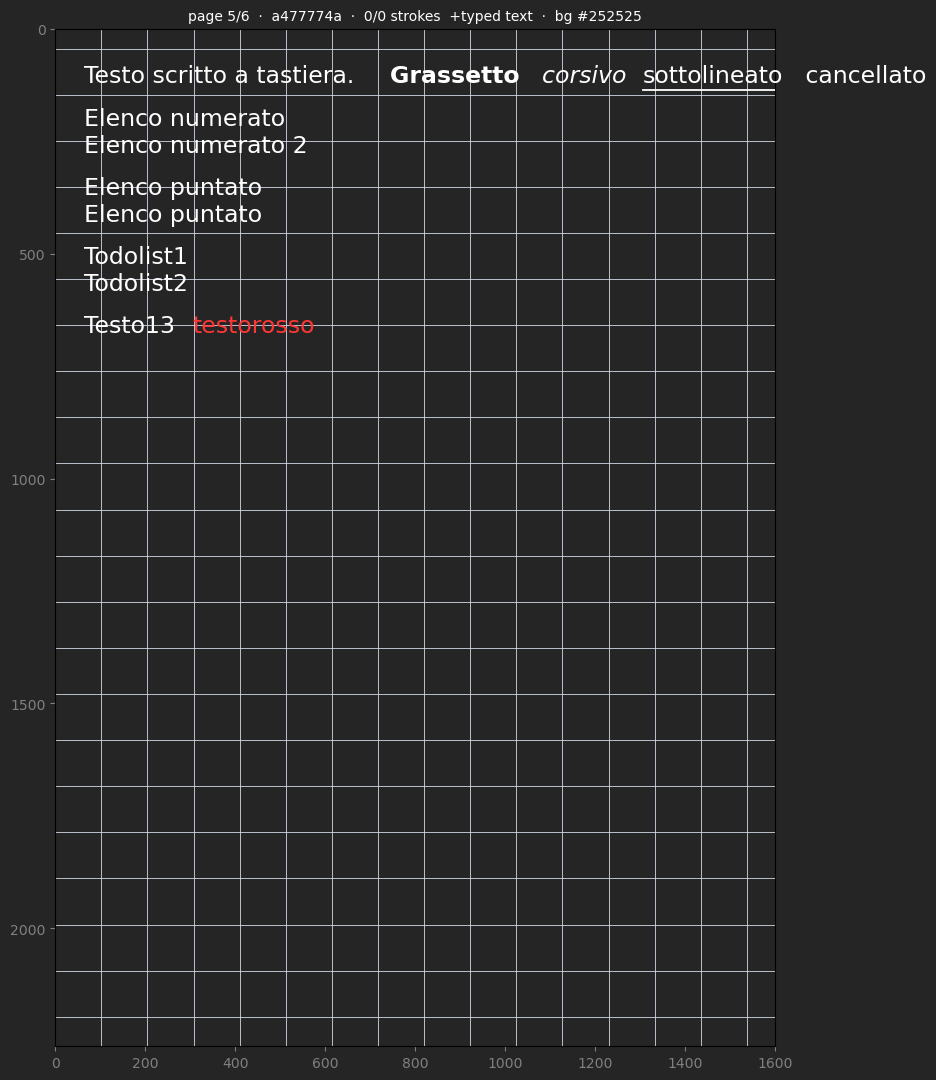

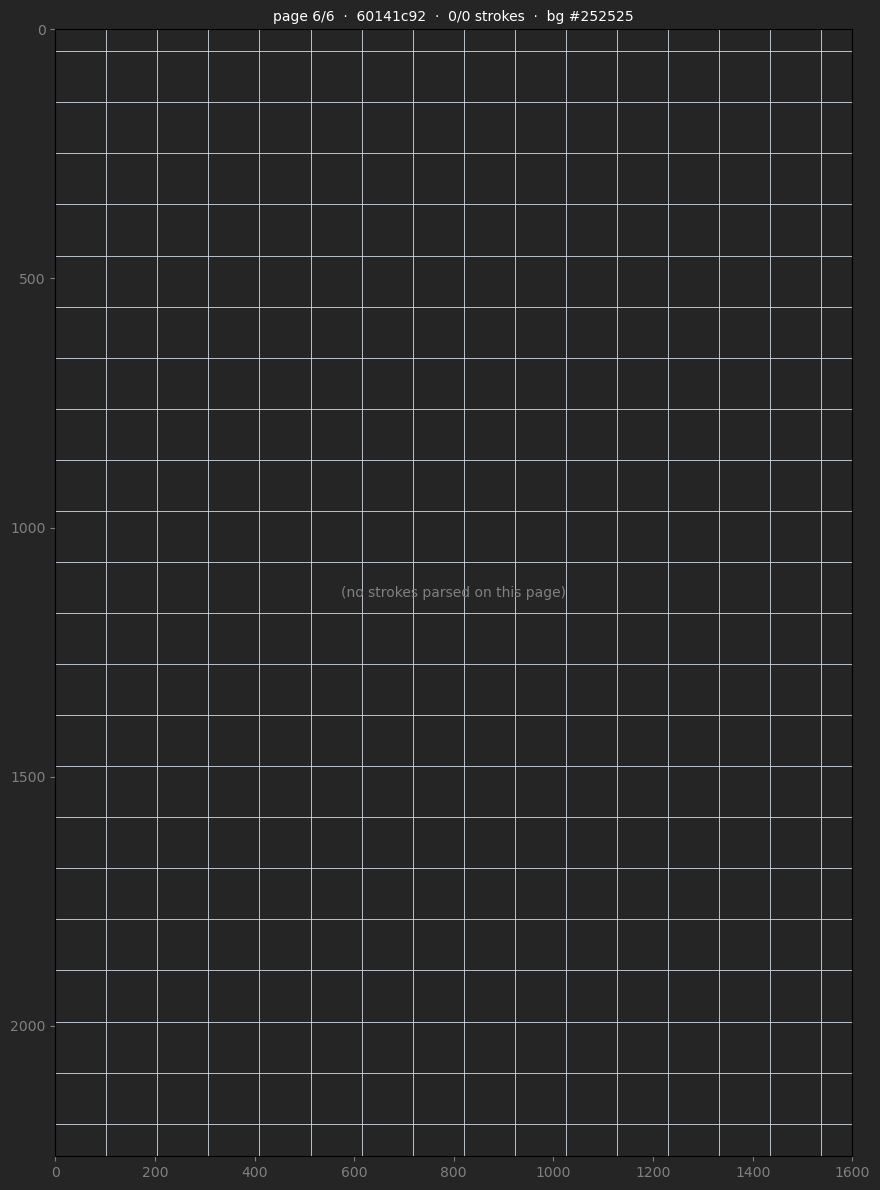

In [16]:
# Render every page full size, one below the other, in true document order.
# Typed ("keyboard") text and tables are stored once per document in note.note, NOT per page, and
# note.note carries no page reference — so their page is a heuristic: typed text goes on the first
# otherwise-empty page (page 5 in the benchmark), and the table on the page the GT shows it on
# (page 4 here). Both are where Samsung Notes displays them.
typed_text = parse_typed_text(load_note(SAMPLE_HANDWRITTEN) or b"")
typed_text_placed = False
tables = parse_tables(load_note(SAMPLE_HANDWRITTEN) or b"")
TABLE_PAGE = 4  # 1-based page index to draw the note's table(s) on (heuristic; see above)
raster_indices = raster_media_indices(SAMPLE_HANDWRITTEN)

for idx, page_name in enumerate(all_pages, start=1):
    _, page_bytes, page_bg = load_page_with_bg(SAMPLE_HANDWRITTEN, page_name)
    page_result = parse_page(page_bytes)
    kept, total = page_result["kept"], page_result["stroke_count"]
    shapes = page_result["shapes"]

    # Imported images (scan_images) and freehand drawings (scan_drawings) render the same way —
    # load each referenced media's bytes for render_page. Dedupe by media index just in case.
    placements = list(page_result["images"]) + scan_drawings(
        page_bytes, page_result["width"], page_result["height"], raster_indices
    )
    images = []
    seen_media = set()
    for pl in placements:
        if pl["media_index"] in seen_media:
            continue
        seen_media.add(pl["media_index"])
        media = load_media_by_index(SAMPLE_HANDWRITTEN, pl["media_index"])
        if media is not None:
            images.append({"bbox": pl["bbox"], "data": media[1]})

    page_tables = [t for t in tables if t["bbox"] is not None] if idx == TABLE_PAGE else []
    is_empty = kept == 0 and not shapes and not images and not page_tables
    shows_typed_text = is_empty and typed_text is not None and not typed_text_placed

    mismatch = "  ⚠ MISMATCH" if kept != total else ""
    extras = "".join(
        part for part in (
            f"  +{len(shapes)} shapes" if shapes else "",
            f"  +{len(images)} images" if images else "",
            f"  +{len(page_tables)} tables" if page_tables else "",
            "  +typed text" if shows_typed_text else "",
        )
    )
    title = (
        f"page {idx}/{len(all_pages)}  ·  {page_name[:8]}  ·  "
        f"{kept}/{total} strokes{extras}{mismatch}  ·  bg {page_bg}"
    )

    fig, ax = plt.subplots(figsize=(9, 12))
    fig.patch.set_facecolor(page_bg)
    # Always render through render_page so the grid template shows even on empty pages.
    render_page(
        ax, page_result["strokes"], page_bg, title=title, shapes=shapes, images=images,
        page_size=(page_result["width"], page_result["height"]), template=page_result["template"],
    )
    for table in page_tables:
        render_table(ax, table)
    if shows_typed_text:
        render_typed_text(ax, typed_text, page_bg)
        typed_text_placed = True
    elif is_empty:
        ax.text(
            0.5, 0.5, "(no strokes parsed on this page)",
            ha="center", va="center", color="gray", transform=ax.transAxes,
        )
    plt.tight_layout()
    plt.show()

---

## Complete SDOCX Format Summary

### Container (ZIP)

| File | Content |
|------|---------|
| `end_tag.bin` | Timestamps (i64 ms epoch), `"Document for S-Pen SDK"` |
| `pageIdInfo.dat` | Page UUID (UTF-16LE) + 2 x 32-byte hashes |
| `media/mediaInfo.dat` | Media filename + SHA-256 + `EOFX` |
| `note.note` | Title, pen tools, background color, dimensions |
| `media/*.spi` | Page thumbnail (Samsung proprietary) |
| `<uuid>.page` | Stroke data (see below) |

### Page file (`.page`)

**Header:**

| Offset | Type | Field |
|--------|------|-------|
| `0x00` | u32 | Base offset (`base`) |
| `0x16` | u32 | Page width |
| `0x1A` | u32 | Page height |
| `0x26` | u16 | UUID length (chars) |
| `0x28` | UTF-16LE | Page UUID |
| `0x80` | 4 x f64 | Content bounding box |
| `base + 0x66` | u32 | Stroke count |

**Stroke records** (starting at `base + 0xB5`, sequential):

| Part | Bytes | Format |
|------|-------|--------|
| Bounding box | 32 | 4 x f64 |
| Metadata | 41 | byte 21: u32 data_len; byte 39: u16 n_points |
| Start point | 16 | 2 x f64 |
| Delta data | data_len | See below |
| Inter-stroke | 71 | UUID + timestamp |

**Delta data layout:**

| Region | Encoding | Description |
|--------|----------|-------------|
| Coordinates | 4-byte groups: `[dx_mag, dx_sign, dy_mag, dy_sign]` | `0x00`=+, `0x80`=-, scale x 1/32 |
| 4-byte gap | — | Separator |
| Pressure | 2-byte pairs x n_points | Sign-mag deltas, cumsum 0–1400 |
| Timestamp | 2-byte pairs x n_points | Sign-mag deltas, monotonic |
| Tilt X | 2-byte pairs x n_points | Sign-mag deltas |
| Tilt Y | 2-byte pairs x n_points | Sign-mag deltas |
| Color marker | `02 00 01 00 00 00` | Precedes color/width |
| Color (optional) | 4 bytes BGRA | Present if 4th byte = `0xFF` |
| Pen width | f32 | Follows color or marker directly |

**Footer:** 26-byte ASCII `"Page for SAMSUNG S-Pen SDK"`

### Base offset

The first u32 (`base`) determines where stroke fields are located. Simple handwritten
files have `base = 0xE3` (227). Files with embedded media (PDF, images) have a larger
base to accommodate object descriptor records in the header.

### Sign-magnitude encoding

Used for both coordinate deltas and per-point channels:
- Each value is a 2-byte pair: `(magnitude, sign_flag)`
- `sign_flag = 0x00`: positive (`+magnitude`)
- `sign_flag = 0x80`: negative (`-magnitude`)
- Bit 7 of the sign byte acts as the sign bit